In [4]:
import matplotlib.gridspec as gridspec

import sys
original_sys_path = sys.path.copy()
sys.path.append('../utils')
from utils_visualization import *

In [5]:
EJ = 3
EJ_over_EL_list = np.linspace(20,30,11)
EJ_over_EC_list = np.linspace(2,10,81)

In [19]:
qbt = scqubits.Fluxonium(EJ = 3,EC = 3/4,EL = 3/20, cutoff = 110,flux = 0,truncated_dim=20)
qbt.matrixelement_table('phi_operator',evals_count=3)

2.4279198170665028e-17

In [524]:
upside_down_phi_element01 = []
upside_down_phi_element12 = []
upside_down_freq01 = []
upside_down_freq12 = []
conventional_phi_element = []
conventional_freq = []
for EJoverEL in EJ_over_EL_list:
    print(f"EJoverEL: {EJoverEL}")
    upside_down_phi_element01.append([])
    upside_down_phi_element12.append([])
    upside_down_freq01.append([])
    upside_down_freq12.append([])
    conventional_phi_element.append([])
    conventional_freq.append([])
    for EJoverEC in tqdm(EJ_over_EC_list, desc = 'sweeping EJoverEC'):
        qbt = scqubits.Fluxonium(EJ = 3,EC = 3/EJoverEC,EL = 3/EJoverEL, cutoff = 110,flux = 0,truncated_dim=20)
        tabel = qbt.matrixelement_table('phi_operator',evals_count=3)
        upside_down_phi_element01[-1].append(np.abs(tabel[1,0]))
        upside_down_phi_element12[-1].append(np.abs(tabel[2,1]))
        upside_down_freq01[-1].append(qbt.eigenvals()[1]-qbt.eigenvals()[0])
        upside_down_freq12[-1].append(qbt.eigenvals()[2]-qbt.eigenvals()[1])

        qbt = scqubits.Fluxonium(EJ = 3,EC = 3/EJoverEC,EL = 3/EJoverEL, cutoff = 110,flux = 0.5,truncated_dim=20)
        conventional_phi_element[-1].append(np.abs(qbt.matrixelement_table('phi_operator',evals_count=3)[0,1]))
        conventional_freq[-1].append(qbt.eigenvals()[1]-qbt.eigenvals()[0])

EJoverEL: 20.0


sweeping EJoverEC: 100%|██████████| 81/81 [04:50<00:00,  3.59s/it]


EJoverEL: 21.0


sweeping EJoverEC: 100%|██████████| 81/81 [05:26<00:00,  4.03s/it]


EJoverEL: 22.0


...

sweeping EJoverEC: 100%|██████████| 81/81 [05:39<00:00,  4.19s/it]


EJoverEL: 29.0


sweeping EJoverEC: 100%|██████████| 81/81 [05:55<00:00,  4.39s/it]


EJoverEL: 30.0


sweeping EJoverEC: 100%|██████████| 81/81 [05:17<00:00,  3.92s/it]


In [525]:
# EJ_over_EC_array, EJ_over_EL_array = np.meshgrid(EJ_over_EC_list, EJ_over_EL_list)

# upside_down_phi_element01_array = np.abs(np.array(upside_down_phi_element01))
# upside_down_freq01_array = np.abs(np.array(upside_down_freq01))

# upside_down_phi_element12_array = np.abs(np.array(upside_down_phi_element12))
# upside_down_freq12_array = np.abs(np.array(upside_down_freq12))

# conventional_phi_element_array = np.abs(np.array(conventional_phi_element))
# conventional_freq_array = np.abs(np.array(conventional_freq))


# import pickle
# with open('data_v2.pkl', 'wb') as f:
#     pickle.dump((EJ_over_EL_list, EJ_over_EC_list, EJ_over_EC_array, EJ_over_EL_array,upside_down_phi_element01_array , upside_down_phi_element12_array , upside_down_freq01_array , upside_down_freq12_array , conventional_phi_element_array ,conventional_freq_array ),f)

In [2]:
import pickle
with open('data_v2.pkl', 'rb') as f:
    (EJ_over_EL_list, EJ_over_EC_list, EJ_over_EC_array, EJ_over_EL_array,upside_down_phi_element01_array , upside_down_phi_element12_array , upside_down_freq01_array , upside_down_freq12_array , conventional_phi_element_array ,conventional_freq_array ) = pickle.load(f)

/var/folders/9k/z8bpg3hj3d9841ggs75xmwxw0000gn/T/ipykernel_43651/707884485.py:63: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



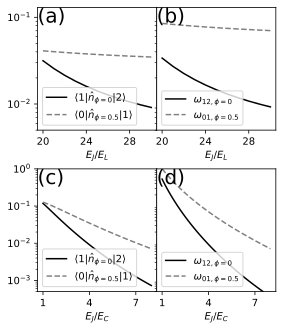

In [521]:
fig = plt.figure(figsize=(4,4.5),constrained_layout=False)

gs = fig.add_gridspec(nrows=1, ncols=2, hspace=0,wspace=0,left=0.12, right=0.95,top=0.98,bottom=0.6)

ax = fig.add_subplot(gs[0])
ax.plot(EJ_over_EL_list,upside_down_element_array[:,30], color='black',label=rf"$\langle 1|\hat{{n}}_{{\phi=0}}|2\rangle$")
ax.plot(EJ_over_EL_list,conventional_element_array[:,30], color='grey',linestyle='--',label=rf"$\langle 0|\hat{{n}}_{{\phi=0.5}}|1\rangle$")
ax.set_yscale('log')
ax.set_ylim(5e-3,1.3e-1)
# ax.set_yticks([1e-2,2e-2,4e-2,6e-2,1e-1])
# ax.set_title('doublet matrix element')
ax.set_xticks([20,24,28])
ax.legend(loc = 'lower left')
ax.set_xlabel(r'$E_J/E_L$')


ax = fig.add_subplot(gs[1])
ax.plot(EJ_over_EL_list,upside_down_freq_array[:,30], color='black',label=rf"$\omega_{{12,\phi=0}}$")
ax.plot(EJ_over_EL_list,conventional_freq_array[:,30], color='grey',linestyle='--',label=rf"$\omega_{{01,\phi=0.5}}$")
ax.set_yscale('log')
ax.set_ylim(5e-3,1.3e-1)
# ax.set_yticks([1e-2,2e-2,4e-2,6e-2,1e-1])
# axes[1].set_title('doublet frequency')
ax.legend(loc = 'lower left')
ax.set_yticks([])
ax.set_xticks([20,24,28])
ax.set_xlabel(r'$E_J/E_L$')
# ax.set_ylabel(r'Frequency/$2\pi$,(GHZ)')
plt.text(0, 1, '(a)', transform=plt.subplot(gs[0]).transAxes, fontsize=20, va='top', color='black')
plt.text(0, 1, '(b)', transform=plt.subplot(gs[1]).transAxes, fontsize=20, va='top', color='black')


gs = fig.add_gridspec(nrows=1, ncols=2, hspace=0,wspace=0,left=0.12, right=0.95,top=0.48,bottom=0.1)

ax = fig.add_subplot(gs[0])
ax.plot(EJ_over_EC_list,upside_down_element_array[-1,:], color='black',label=rf"$\langle 1|\hat{{n}}_{{\phi=0}}|2\rangle$")
ax.plot(EJ_over_EC_list,conventional_element_array[-1,:], color='grey',linestyle='--',label=rf"$\langle 0|\hat{{n}}_{{\phi=0.5}}|1\rangle$")
ax.set_yscale('log')
ax.set_ylim(5e-4,1)
# ax.set_yticks([1e-2,2e-2,4e-2,6e-2,1e-1])
# ax.set_title('doublet matrix element')
ax.set_xticks([1,4,7])
ax.legend(loc = 'lower left')
ax.set_xlabel(r'$E_J/E_C$')


ax = fig.add_subplot(gs[1])
ax.plot(EJ_over_EC_list,upside_down_freq_array[-1,:], color='black',label=rf"$\omega_{{12,\phi=0}}$")
ax.plot(EJ_over_EC_list,conventional_freq_array[-1,:], color='grey',linestyle='--',label=rf"$\omega_{{01,\phi=0.5}}$")
ax.set_yscale('log')
ax.set_ylim(5e-4,1)
# ax.set_yticks([1e-2,2e-2,4e-2,6e-2,1e-1])
# axes[1].set_title('doublet frequency')
ax.legend(loc = 'lower left')
ax.set_yticks([])
ax.set_xticks([1,4,7])
ax.set_xlabel(r'$E_J/E_C$')
# ax.set_ylabel(r'Frequency/$2\pi$,(GHZ)')

plt.text(0, 1, '(c)', transform=plt.subplot(gs[0]).transAxes, fontsize=20, va='top', color='black')
plt.text(0, 1, '(d)', transform=plt.subplot(gs[1]).transAxes, fontsize=20, va='top', color='black')

plt.tight_layout()
fig.savefig('fig04.pdf')

# coherence time estimation

In [6]:
def one_over_f_loss_rate(omega,EL,phi_element):
    return 8*np.pi**3*EL**2*(5.21*1e-6)**2*phi_element**2/omega

def dielectric_loss_rate(omega,EC,phi_element):
    temp_in_mK = 42
    Q_cap = 2.5*1e5
    beta = 1/(1.380649*1e-23 * temp_in_mK*1e-3)
    return omega**2/(4*EC*Q_cap)/np.tanh(beta*omega/2)*phi_element**2

def one_over_f_dephasing_rate(omega,EL):
    A = 1e-6
    return omega/EL/A**2

conventional_dielectric_lifetime = np.zeros((len(EJ_over_EL_list) ,len(EJ_over_EC_list)))
conventional_one_over_f_loss_lifetime = np.zeros((len(EJ_over_EL_list) ,len(EJ_over_EC_list)))
conventional_dephasing_lifetime = np.zeros((len(EJ_over_EL_list) ,len(EJ_over_EC_list)))

upside_down01_dielectric_lifetime = np.zeros((len(EJ_over_EL_list) ,len(EJ_over_EC_list)))
upside_down01_one_over_f_loss_lifetime = np.zeros((len(EJ_over_EL_list) ,len(EJ_over_EC_list)))
upside_down01_dephasing_lifetime = np.zeros((len(EJ_over_EL_list) ,len(EJ_over_EC_list)))

upside_down12_dielectric_lifetime = np.zeros((len(EJ_over_EL_list) ,len(EJ_over_EC_list)))
upside_down12_one_over_f_loss_lifetime = np.zeros((len(EJ_over_EL_list) ,len(EJ_over_EC_list)))
upside_down12_dephasing_lifetime = np.zeros((len(EJ_over_EL_list) ,len(EJ_over_EC_list)))

for i in range(len(EJ_over_EL_list)):
    for j in range(len(EJ_over_EC_list)):
        conventional_dielectric_lifetime[i,j] = dielectric_loss_rate(conventional_freq_array[i,j],EJ/EJ_over_EC_list[j],conventional_phi_element_array[i,j])
        conventional_one_over_f_loss_lifetime[i,j] = one_over_f_loss_rate(conventional_freq_array[i,j],EJ/EJ_over_EL_list[i],conventional_phi_element_array[i,j])
        conventional_dephasing_lifetime[i,j] = one_over_f_dephasing_rate(conventional_freq_array[i,j],EJ/EJ_over_EL_list[i])

        upside_down01_dielectric_lifetime[i,j] = dielectric_loss_rate(upside_down_freq01_array[i,j],EJ/EJ_over_EC_list[j],upside_down_phi_element01_array[i,j])
        upside_down01_one_over_f_loss_lifetime[i,j] = one_over_f_loss_rate(upside_down_freq01_array[i,j],EJ/EJ_over_EL_list[i],upside_down_phi_element01_array[i,j])
        upside_down01_dephasing_lifetime[i,j] = one_over_f_dephasing_rate(upside_down_freq01_array[i,j],EJ/EJ_over_EL_list[i])

        upside_down12_dielectric_lifetime[i,j] = dielectric_loss_rate(upside_down_freq12_array[i,j],EJ/EJ_over_EC_list[j],upside_down_phi_element12_array[i,j])
        upside_down12_one_over_f_loss_lifetime[i,j] = one_over_f_loss_rate(upside_down_freq12_array[i,j],EJ/EJ_over_EL_list[i],upside_down_phi_element12_array[i,j])
        upside_down12_dephasing_lifetime[i,j] = one_over_f_dephasing_rate(upside_down_freq12_array[i,j],EJ/EJ_over_EL_list[i])


In [12]:

i=5
j=5
omega = upside_down_freq12_array[i,j]
EC = EJ/EJ_over_EC_list[j]
phi_element= upside_down_phi_element12_array[i,j]
temp_in_mK = 42
Q_cap = 2.5*1e5
beta = 1/(1.380649*1e-23 * temp_in_mK*1e-3)
omega**2/(4*EC*Q_cap), 1/np.tanh(beta*omega/2), phi_element**2

(3.5538830517885132e-09, 1.0, 0.0)

In [9]:
import plotly.graph_objects as go

fig = go.Figure(data=[
    go.Surface(z=conventional_dielectric_lifetime,x=EJ_over_EL_array,y = EJ_over_EC_array, colorscale = ['red','red'],opacity=1,showscale= False,name="upside_down_element"),
    go.Surface(z=upside_down01_dielectric_lifetime,x=EJ_over_EL_array,y = EJ_over_EC_array, colorscale = ['red','red'],opacity=1,showscale= False,name="upside_down_element"),
    go.Surface(z=upside_down12_dielectric_lifetime,x=EJ_over_EL_array,y = EJ_over_EC_array, colorscale = ['red','red'],opacity=1,showscale= False,name="upside_down_element"),

    # go.Surface(z=upside_down12_dephasing_lifetime,x=EJ_over_EL_array,y = EJ_over_EC_array, colorscale = ['darkorange','darkorange'],opacity=1,showscale= False,name="conventional_element"),
])

fig.update_layout(scene=dict(
    xaxis_title='EJ/EL', 
    yaxis_title='EJ/EC',  
    zaxis_title='element'  
))
fig.update_layout(width=700, height=700)
fig.show()

In [ ]:
import numpy as np
from scipy.optimize import curve_fit

def model(x, A, p,b):
    return A / np.power(x, p)+b

params, covariance = curve_fit(model, x_data, y_data)

# Extract the fitted parameters
A_fit, p_fit = params

# Print the results
print("Fitted A:", A_fit)
print("Fitted p:", p_fit)


/var/folders/9k/z8bpg3hj3d9841ggs75xmwxw0000gn/T/ipykernel_43651/2104079336.py:24: MatplotlibDeprecationWarning:

The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.



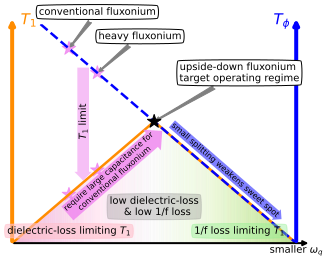

In [487]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize
from matplotlib.patches import ArrowStyle
fig  = plt.figure(figsize=(5,3.5),constrained_layout=False)
gs = fig.add_gridspec(nrows=1, ncols=1,left=0.03, right=0.82,top=0.92,bottom=0.05)
ax = fig.add_subplot(gs[0])
ax.set_xlim(0, 100)
y_max = 90
ax.set_ylim(0, y_max)
ax.tick_params(axis='both', which='both', length=0)
ax.set_xticks([])
ax.set_yticks([])


ax.plot(np.linspace(0, 50, 2), np.linspace(0,50, 2), color='darkorange',linewidth=2.5,alpha=1)
ax.plot(np.linspace(50, 100, 2), np.linspace(50,0, 2), color='darkorange',linewidth=2.5,alpha=1)
ax.plot(np.linspace(100-y_max, 100, 2), np.linspace(y_max,0, 2), color='blue',linewidth=2.5,alpha=1,linestyle='--')

cnt = plt.contourf(range(100), range(80), np.array([[z] * 80 for z in range(100)]).T, 500,
                   cmap='PiYG',#cmap='twilight_shifted',
                   norm = Normalize(vmin=-50, vmax=150),
                   alpha=0.3)
for c in cnt.collections:
    c.set_edgecolor("face")

x = np.linspace(0, 101, 100)
ax.fill_between(x, x, 100, color='white',linewidth=0,alpha=1)
ax.fill_between(x, 100-x, 100, color='white',linewidth=0,alpha=1)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)



xarrow = ax.annotate('', xy=[0, 0], xycoords='data', xytext=[105,0], 
            textcoords='data', ha='left', va='center',
            arrowprops=dict( arrowstyle='<|-',
                facecolor='black', 
                linewidth=2,
                alpha = 1,
                ))
ax.text(100,-3,r'''smaller $\omega_q$''',va='center',ha = 'center')
        

yarrow = ax.annotate('' , [0,0], xycoords='data', 
            xytext=[0,y_max+3], textcoords='data', 
            ha='center', va='center', 
            arrowprops=dict( arrowstyle='<|-',
                edgecolor='darkorange', 
                linewidth=4,
                alpha = 1,
                ))
ax.text(3,y_max,r'$T_1$',color='darkorange',fontsize=15)

yarrow = ax.annotate('' , [100,0], xycoords='data', 
            xytext=[100,y_max+3], textcoords='data', 
            ha='center', va='center', 
            arrowprops=dict( arrowstyle='<|-',
                edgecolor='blue',
                linewidth=4,
                ))
ax.text(92,y_max,r'$T_\phi$',color='blue',fontsize=15)



# t = ax.text(65, 76, rf"use upside-down",
#             ha="center", va="center", rotation=-14, size=9,
#             bbox=dict(boxstyle="rarrow,pad=0.2",
#                       fc="grey", ec=None, lw=0,alpha=0.5))

conventional_t_phi = 80
ax.scatter(20,conventional_t_phi, marker = '*', color='violet', s=200,alpha=0.8)
t = ax.text(25, 25/2+75/2, rf"           $T_1$ limit           ",
            ha="center", va="center", rotation=90, size=10,
            bbox=dict(boxstyle="larrow,pad=0.1",
                      fc="violet", ec=None, lw=0,alpha=0.5))
ax.scatter(20,20, marker='*', color='violet', s=200,alpha=0.8)
ax.annotate("conventional fluxonium",
            xy=(20, conventional_t_phi), xycoords='data',
            xytext=(30, conventional_t_phi+15), textcoords='data',
            size= 10,va="center", ha="center",
            bbox=dict(boxstyle="round4", fc="w",ec='black'),
            arrowprops=dict(arrowstyle="fancy",connectionstyle="arc3",fc="grey",ec='grey',lw=1))

heavy_t_phi = 70
ax.scatter(30,heavy_t_phi, marker = '*', color='violet', s=200,alpha=0.8)
ax.scatter(30,30, marker='*', color='violet', s=200,alpha=0.8)

ax.annotate("heavy fluxonium",
            xy=(30, heavy_t_phi), xycoords='data',
            xytext=(45, heavy_t_phi+15), textcoords='data',
            size= 10,va="center", ha="center",
            bbox=dict(boxstyle="round4", fc="w",ec='black'),
            arrowprops=dict(arrowstyle="fancy",connectionstyle="arc3",fc="grey",ec='grey',lw=1))


# ax.text(5,95,rf'''conventional fluxonium
#             too much $T_\phi$
#     $T_1$ still dielectric-loss-limited''',color='blue')


# ax.text(30,10,rf'''upside-down fluxonium
# lose some $T_\phi$ due to
# shaper avoided crossing
#     $T_1$ becomes 
#     1/f noise-limited''',color='orange')

ax.scatter(50,50, marker='*', color='black', s=200,alpha=1,zorder=100)
ax.annotate('''upside-down fluxonium 
target operating regime''',
            xy=(50, 50), xycoords='data',
            xytext=(80, 70), textcoords='data',
            size= 10,va="center", ha="center",
            bbox=dict(boxstyle="round4", fc="w",ec='black'),
            arrowprops=dict(arrowstyle="fancy",connectionstyle="arc3",fc="grey",ec='grey',lw=1))


ax.text(20, 5, f"dielectric-loss limiting $T_1$",
            size= 10,va="center", ha="center",
            bbox=dict(boxstyle="round4", fc="pink",ec='pink',alpha=0.6))

ax.text(80, 5, f"1/f loss limiting $T_1$",
            size= 10,va="center", ha="center",
            bbox=dict(boxstyle="round4", fc="lightgreen",ec='lightgreen',alpha=0.4))

ax.text(50, 15, f'''low dielectric-loss
  & low 1/f loss''',
            size= 10,va="center", ha="center",
            bbox=dict(boxstyle="round4", fc="grey",ec='grey',alpha=0.3))


t = ax.text(35, 28, rf'''require large capacitance for
conventional fluxonium''',
            ha="center", va="center", rotation=41, size=8,
            bbox=dict(boxstyle="rarrow,pad=0.1",
                      fc="violet", ec=None, lw=0,alpha=0.8))


t = ax.text(75, 30, rf'''small splitting weakens sweet spot''',
            ha="center", va="center", rotation=-41, size=8,
            bbox=dict(boxstyle="rarrow,pad=0.1",
                      fc="blue", ec=None, lw=0,alpha=0.5))


plt.show()
fig.savefig('fig05.pdf')